# AI kunskapskontroll 2026 del 2

## EDA

## Start by loading & describing

In [32]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    log_loss,
    top_k_accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)


In [33]:

# Externaliserar funktioner för att det ska var enkla att följa röda tråden

def load_mnist():
    "Ladda Mnist, ""Load MNIST, print description and shape, return (X, y) with integer labels."""
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    print(mnist.DESCR)
    print("Shape:", mnist.data.shape)
    return mnist.data, mnist.target.astype(int)


def plot_class_distribution(y, title="Class distribution"):
    """Bar chart of class counts."""
    pd.Series(y).value_counts().sort_index().plot(kind="bar")
    plt.title(title)
    plt.show()


def plot_pixel_distribution(X, title="Pixel intensity distribution", bins=50):
    """Histogram of pixel intensities."""
    plt.hist(X.flatten(), bins=bins)
    plt.title(title)
    plt.show()


def plot_average_digits(X, y):
    """Show mean image for each unique class label."""
    for digit in np.unique(y):
        plt.imshow(X[y == digit].mean(axis=0).reshape(28, 28), cmap="gray")
        plt.title(f"Average {digit}")
        plt.show()


def prepare_data(X, y, scale=True, test_size=0.2, random_state=42):
    """Optionally scale and split into train/test sets."""
    X_proc = X / 255.0 if scale else X
    return train_test_split(X_proc, y, test_size=test_size, random_state=random_state)


def train_logistic_regression(X_train, y_train, max_iter=1000):
    """Train and return a LogisticRegression model."""
    model = LogisticRegression(max_iter=max_iter)
    model.fit(X_train, y_train)
    return model


def train_or_load_svc(X_train, y_train, model_path='mnist_svc_model.joblib', kernel='rbf'):
    """Load SVC from disk if available, otherwise train and save it."""
    if os.path.exists(model_path):
        print("Loading SVC model from file...")
        return joblib.load(model_path)
    print("Training SVC model...")
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    
    # det har visat sig att SVC tar väldigt lång tid att träna, så vi sparar modellen på disk
    joblib.dump(model, model_path)
    print("SVC model saved to file.")
    return model


def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """Build, compile and return a CNN model."""
    from tensorflow import keras
    from tensorflow.keras import layers
    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="mnist_cnn")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model


#
def train_cnn(model, X_train, y_train, image_shape=(28, 28, 1), epochs=10, batch_size=128, validation_split=0.2):
    """Reshape X_train and fit the CNN. Returns (history, X_train_reshaped)."""
    X_reshaped = X_train.reshape(-1, *image_shape)
    history = model.fit(X_reshaped, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=validation_split, verbose=1)
    return history, X_reshaped


def evaluate_predictions(y_true, y_pred, name, y_proba=None):
    """Compute and print a unified set of metrics for any classifier."""
    scores = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    }

    if y_proba is not None:
        labels = np.unique(y_true)
        scores["log_loss"] = log_loss(y_true, y_proba, labels=labels)
        scores["top3_accuracy"] = top_k_accuracy_score(y_true, y_proba, k=3, labels=labels)

    print(f"\n=== {name} ===")
    for key in ["accuracy", "f1_macro", "f1_weighted", "balanced_accuracy", "mcc", "cohen_kappa"]:
        print(f"{key}: {scores[key]:.4f}")
    if y_proba is not None:
        for key in ["log_loss", "top3_accuracy"]:
            print(f"{key}: {scores[key]:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix - {name}")
    plt.show()

    return scores


def evaluate_sklearn_model(model, X_test, y_test, name):
    """Evaluate sklearn model with unified metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)


def evaluate_cnn(model, X_test, y_test, image_shape=(28, 28, 1), name="CNN"):
    """Evaluate CNN model with same metrics as sklearn models."""
    X_reshaped = X_test.reshape(-1, *image_shape)
    y_proba = model.predict(X_reshaped, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)


In [23]:
X, y = load_mnist()


**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

## Is our data balanced?

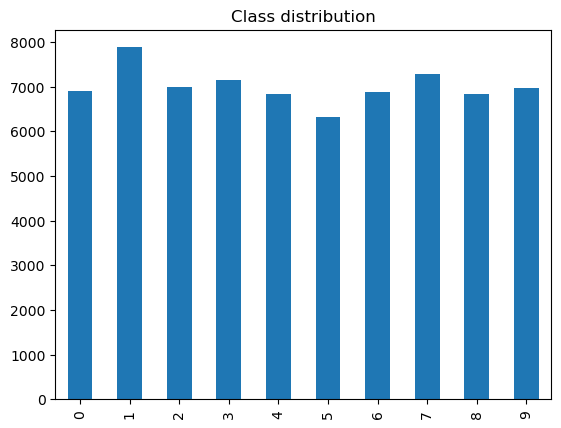

In [24]:
plot_class_distribution(y)


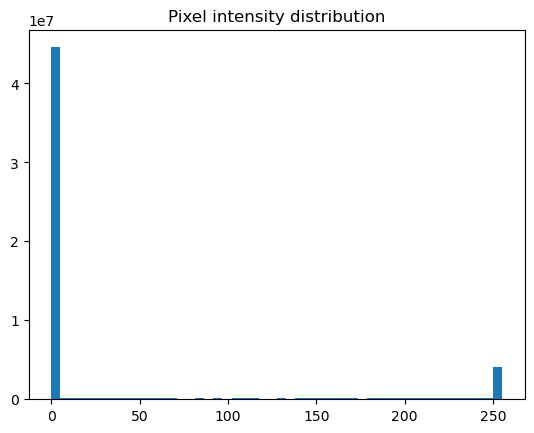

In [25]:
plot_pixel_distribution(X)


## Visualize all. Average image per digit

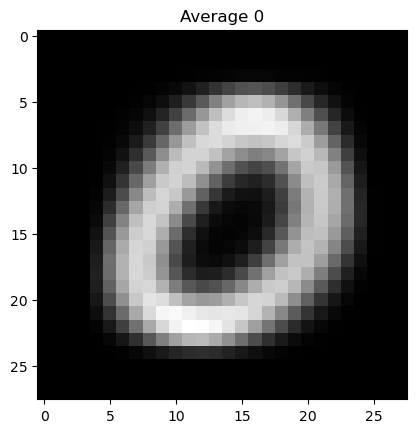

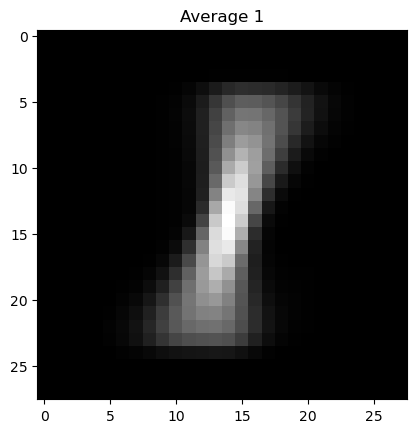

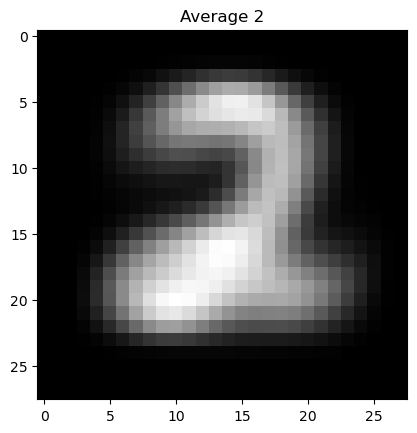

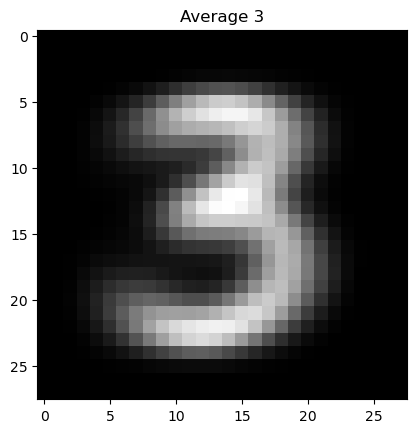

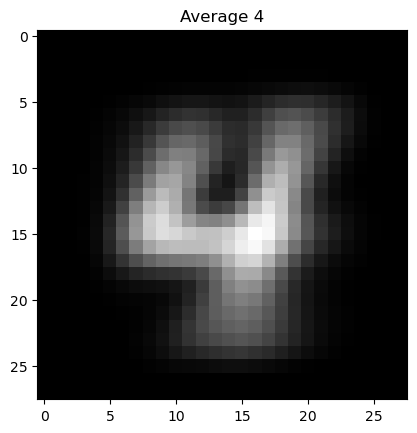

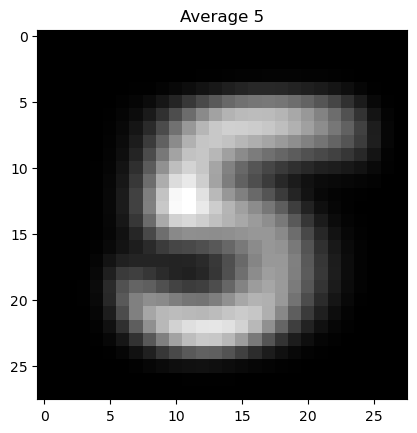

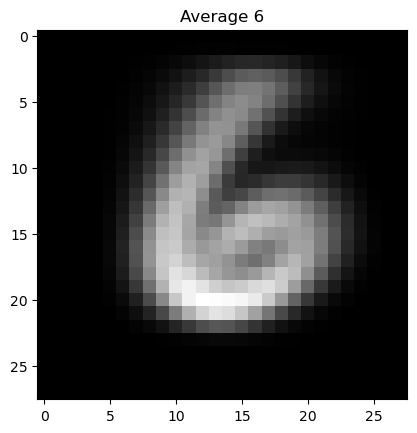

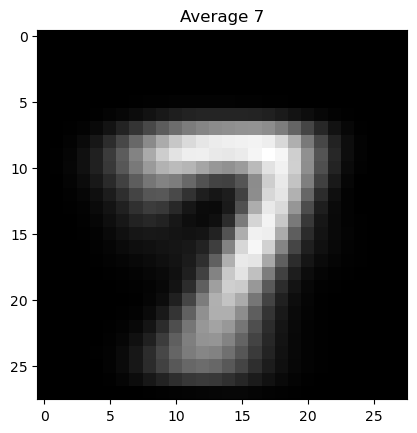

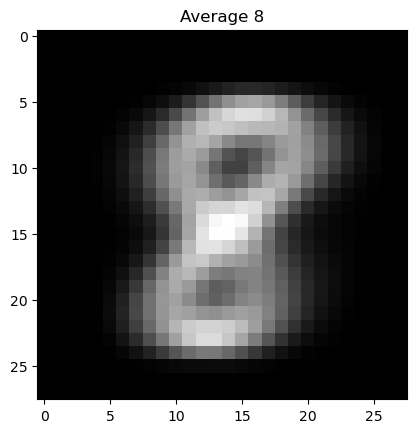

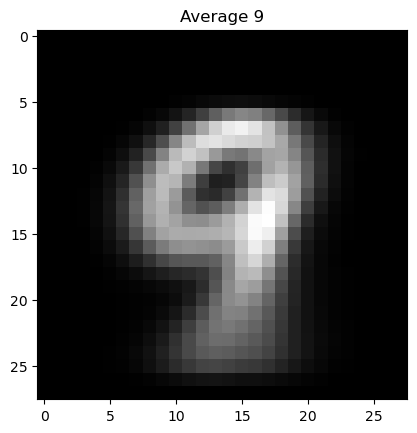

In [26]:
plot_average_digits(X, y)


## Split data into train, valid, test

In [27]:
X_train, X_test, y_train, y_test = prepare_data(X, y)


## Step Training:

In [28]:
linreg_model = train_logistic_regression(X_train, y_train)
svc_model = train_or_load_svc(X_train, y_train)


Loading SVC model from file...


### About the CNN summary table
When Keras prints `Model: "sequential_1"`, that is only an automatic model name (first, second, etc. Sequential model in the session).
In this notebook the model is now explicitly named `mnist_cnn`, so the summary becomes easier to read.

How to read the table:
- `Layer (type)`: each operation in the network, such as Conv2D, MaxPooling2D, Flatten, Dense.
- `Output Shape`: tensor shape after that layer.
- `Param #`: number of trainable parameters in the layer.
- `Total params / Trainable params`: model capacity and what is updated during training.

This table explains architecture size/complexity, while the confusion matrix and F1/accuracy explain prediction quality.

In [19]:
%pip install tensorflow -q
import tensorflow as tf

model_cnn = build_cnn()
history, X_train_cnn = train_cnn(model_cnn, X_train, y_train)


Note: you may need to restart the kernel to use updated packages.


c:\Users\alexa\.conda\envs\CondaPython3_13_lab12\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9098 - loss: 0.2971 - val_accuracy: 0.9751 - val_loss: 0.0811
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9705 - loss: 0.0938 - val_accuracy: 0.9813 - val_loss: 0.0590
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9775 - loss: 0.0692 - val_accuracy: 0.9830 - val_loss: 0.0561
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9819 - loss: 0.0564 - val_accuracy: 0.9880 - val_loss: 0.0376
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9848 - loss: 0.0480 - val_accuracy: 0.9881 - val_loss: 0.0372
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9866 - loss: 0.0421 - val_accuracy: 0.9882 - val_loss: 0.0369
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9888 - loss: 0.0357 - val_accuracy: 0.9907 - val_loss: 0.0323
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9885 - loss: 0.0345 - val_accu

## Step Evaluation:


=== Logistic Regression ===
accuracy: 0.9201
f1_macro: 0.9191
f1_weighted: 0.9199
balanced_accuracy: 0.9190
mcc: 0.9112
cohen_kappa: 0.9111
log_loss: 0.2963
top3_accuracy: 0.9839

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.95      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



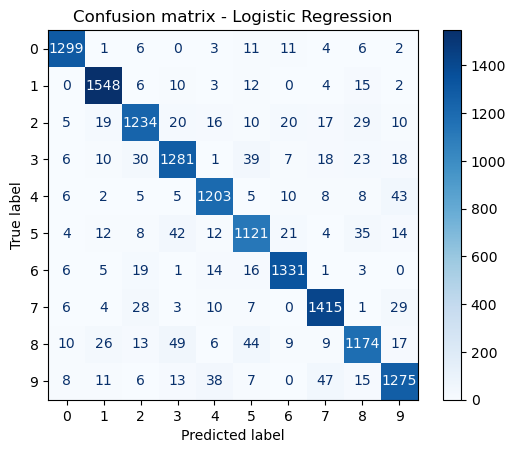

In [ ]:
scores_lr = evaluate_sklearn_model(linreg_model, X_test, y_test, "Logistic Regression")
scores_svc = evaluate_sklearn_model(svc_model, X_test, y_test, "SVC")
scores_cnn = evaluate_cnn(model_cnn, X_test, y_test, name="CNN")

comparison_df = pd.DataFrame([scores_lr, scores_svc, scores_cnn]).set_index("model")
display(comparison_df.sort_values("f1_macro", ascending=False))
